In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LinearRegression
import urllib.request
import json
from dateutil import parser

In [6]:
data = pd.read_csv('primary-time-series.csv')
data

,x,y,id,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,NaN,NaN,53b98dac-d248-40ff-ac46-41aacdf790d5,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2026-06-04 02:15:00+00:00,34700.0,ft^3/s,Provisional,NaN,2026-06-04 02:29:53.194711+00:00
1,NaN,NaN,1f4bc00d-170d-45f7-a1ee-82260c18a019,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2026-06-04 02:00:00+00:00,34900.0,ft^3/s,Provisional,NaN,2026-06-04 02:29:53.194711+00:00
2,NaN,NaN,3c5bf8c7-61b0-4f8b-ae98-0a98516c6e63,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2026-06-04 01:45:00+00:00,35000.0,ft^3/s,Provisional,NaN,2026-06-04 02:29:53.194711+00:00
3,NaN,NaN,faea995e-32c9-44de-9322-a3fbdaf9dd93,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2026-06-04 01:30:00+00:00,35200.0,ft^3/s,Provisional,NaN,2026-06-04 02:29:53.194711+00:00
4,NaN,NaN,e1ca85c9-b451-495c-b9e5-9e60ad0ef6bf,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2026-06-04 01:15:00+00:00,35400.0,ft^3/s,Provisional,NaN,2026-06-04 01:26:22.498766+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34606,NaN,NaN,62932b61-7b2f-4afc-bed8-994f7436c02f,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2025-06-04 04:00:00+00:00,56300.0,ft^3/s,Approved,NaN,2025-09-26 14:15:09.114690+00:00
34607,NaN,NaN,4a760149-da01-4cdc-a887-8d255e51f47c,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2025-06-04 03:45:00+00:00,56500.0,ft^3/s,Approved,NaN,2025-09-26 14:15:09.114690+00:00
34608,NaN,NaN,afbaf1e9-4c52-4d42-ac3a-67f774c9728a,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2025-06-04 03:30:00+00:00,56800.0,ft^3/s,Approved,NaN,2025-09-26 14:15:09.114690+00:00
34609,NaN,NaN,6ad958f5-0b9c-4920-ba34-9d3f7117c462,8ffbc547348a40d3b9296d0ac3625d68,USGS-13334300,60,11,2025-06-04 03:15:00+00:00,56900.0,ft^3/s,Approved,NaN,2025-09-26 14:15:09.114690+00:00


In [7]:
data['date_time'] = pd.to_datetime(data['time'])
#data.set_index('date_time', inplace=True)
#data.plot(y='value', ylabel='Discharge cubic ft per sec')

In [5]:
#barData = data['value'].groupby(data.index.month).std()
#barData.plot.bar(y='value', ylabel='Standard deviation of discharge', rot=0)

Prediction on 2026-07-04: 37852.96 ft/sec^3


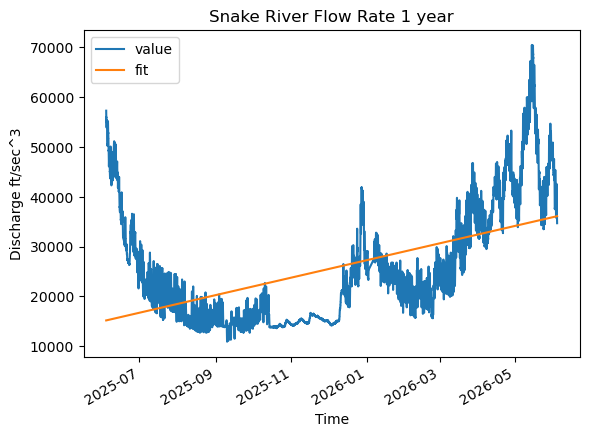

In [8]:
regressor = LinearRegression()
df_dis = pd.DataFrame(data[['value', 'date_time']])
df_dis['timestamp'] = data['date_time'].astype(np.int64)
df_dis.set_index('timestamp', inplace=True)
df_dis = df_dis.dropna(subset=['value'])#gets rid of nan

array = df_dis.index.values.reshape(-1, 1)
regressor.fit(array, df_dis['value'])
y_fit = regressor.predict(array)

predict_date = pd.Timestamp('2026-07-04 12:00:00')
predict_date_df = pd.DataFrame({np.int64(predict_date.value)})
prediction = regressor.predict(predict_date_df)

df_fit = df_dis.assign(fit = y_fit)
df_fit.plot(kind='line', title='Snake River Flow Rate 1 year',  xlabel='Time', ylabel='Discharge ft/sec^3', x='date_time')
print(f"Prediction on 2026-07-04: {prediction[0]:.2f} ft/sec^3")

Prediction on 2026-07-04: 28149.96 ft/sec^3


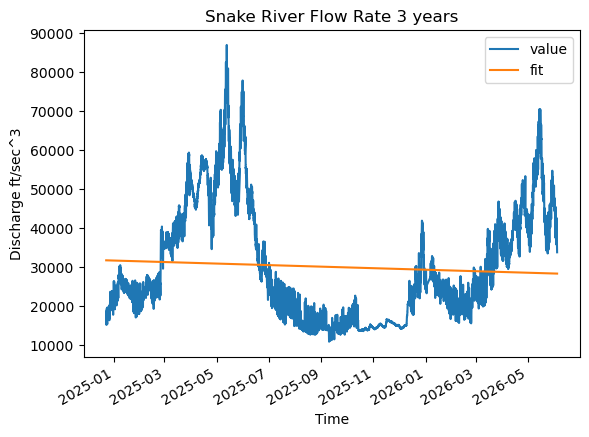

In [9]:
data3y = pd.read_csv('3yearsnakeriver.csv')
data3y['date_time'] = pd.to_datetime(data3y['time'])
regressor3y = LinearRegression()
df_dis3y = pd.DataFrame(data3y[['value', 'date_time']])
df_dis3y['timestamp'] = data3y['date_time'].astype(np.int64)
df_dis3y.set_index('timestamp', inplace=True)
df_dis3y = df_dis3y.dropna(subset=['value'])#gets rid of nan

array3y = df_dis3y.index.values.reshape(-1, 1)
regressor3y.fit(array3y, df_dis3y['value'])
y_fit3y = regressor3y.predict(array3y)

predict_date3y = pd.Timestamp('2026-07-04 12:00:00')
predict_date_df3y = pd.DataFrame({np.int64(predict_date3y.value)})
prediction3y = regressor3y.predict(predict_date_df3y)

df_fit3y = df_dis3y.assign(fit = y_fit3y)
df_fit3y.plot(kind='line', title='Snake River Flow Rate 3 years',  xlabel='Time', ylabel='Discharge ft/sec^3', x='date_time')
print(f"Prediction on 2026-07-04: {prediction3y[0]:.2f} ft/sec^3")

In [3]:
url = (f"https://waterservices.usgs.gov/nwis/iv/?sites=13334300&parameterCd=00060&startDT=2024-01-01&endDT=2026-01-01&format=json")
response = urllib.request.urlopen(url).read().decode('utf-8')

In [8]:
data = json.loads(response)
flow_data = data['value']['timeSeries'][0]['values'][0]['value']

lists = []
for data_point in flow_data:
    time = parser.parse(data_point['dateTime'])
    row = [time, float(data_point['value'])]
    lists.append(row)

In [11]:
df = pd.DataFrame(lists, columns=['datetime', 'flow'])
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime').sort_index()

df = df.resample('1D').mean()
for i in range(1, 15):
    df[f'day_{i}'] = df['flow'].shift(i)

df['target'] = df['flow'].shift(-1)
df = df.dropna()
days = [
    'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6', 'day_7', 'day_8', 'day_9', 'day_10', 'day_11', 'day_12', 'day_13', 'day_14'
]
X = df[days].values
y = df['target'].values
df.head()

,flow,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,target
datetime,,,,,,,,,,,,,,,,
2024-01-15 00:00:00+00:00,20712.500000,19946.875000,17972.916667,18695.744681,18577.659574,18050.000000,19111.458333,17109.375000,16992.708333,17348.958333,18620.833333,18384.375000,18343.750000,16809.375000,17137.500000,19833.333333
2024-01-16 00:00:00+00:00,19833.333333,20712.500000,19946.875000,17972.916667,18695.744681,18577.659574,18050.000000,19111.458333,17109.375000,16992.708333,17348.958333,18620.833333,18384.375000,18343.750000,16809.375000,17934.375000
2024-01-17 00:00:00+00:00,17934.375000,19833.333333,20712.500000,19946.875000,17972.916667,18695.744681,18577.659574,18050.000000,19111.458333,17109.375000,16992.708333,17348.958333,18620.833333,18384.375000,18343.750000,19700.000000
2024-01-18 00:00:00+00:00,19700.000000,17934.375000,19833.333333,20712.500000,19946.875000,17972.916667,18695.744681,18577.659574,18050.000000,19111.458333,17109.375000,16992.708333,17348.958333,18620.833333,18384.375000,18552.083333
2024-01-19 00:00:00+00:00,18552.083333,19700.000000,17934.375000,19833.333333,20712.500000,19946.875000,17972.916667,18695.744681,18577.659574,18050.000000,19111.458333,17109.375000,16992.708333,17348.958333,18620.833333,18711.458333


In [24]:
split = int(.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

<Axes: title={'center': 'Snake River Flow Rate'}, xlabel='Month', ylabel='Discharge (ft³/s)'>

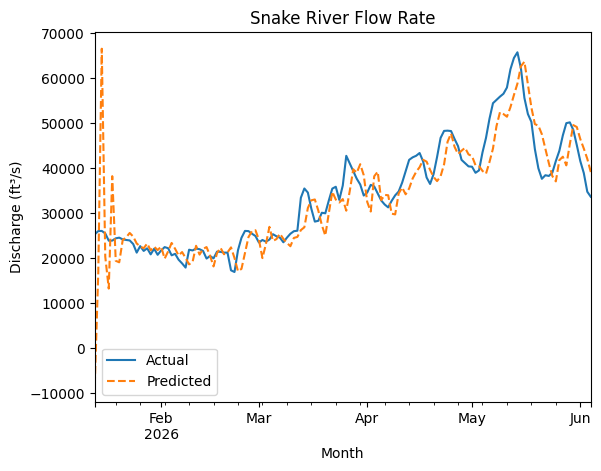

In [28]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=dates_test)

results_df.plot(style=['-', '--'], title='Snake River Flow Rate', ylabel='Discharge (ft³/s)', xlabel='Month')